## Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv(r'C:\Users\user\Downloads\Machine Learning 2\Machine-Learning-2-Week-2-Project\marketing_campaign.csv', sep='\t')
print("Shape:", df.shape)
df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Income    24
dtype: int64


#### Data Cleaning

In [6]:
#Dropping rows with missing values and the ones I dont need
df.dropna(subset=['Income'], inplace=True)
df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], inplace=True)

In [7]:
#Converting Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

print(df.shape)
print("Missing values:", df.isnull().sum().sum())

(2216, 26)
Missing values: 0


#### Feature Engineering
I created a few more rows that will be useful for clustering

In [9]:
#Age
df['Age'] = 2024 - df['Year_Birth']

#Total amount spent across all categories
df['Total_Spent'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                     df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

#Total number of purchases across all channels
df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] +
                         df['NumStorePurchases'] + df['NumDealsPurchases'])

#How long the customer has been with the company(in days)
df['Days_As_Customer'] = (pd.Timestamp('2024-01-01') - df['Dt_Customer']).dt.days

#Total number of children at home
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

#Total campaigns accepted
df['Total_Campaigns_Accepted'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] +
                                   df['AcceptedCmp3'] + df['AcceptedCmp4'] +
                                   df['AcceptedCmp5'] + df['Response'])

In [10]:
#Dropping columns I no longer need after feature engineering
df.drop(columns=['Year_Birth', 'Dt_Customer', 'Kidhome', 'Teenhome',
                 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                 'MntSweetProducts', 'MntGoldProds',
                 'NumWebPurchases', 'NumCatalogPurchases',
                 'NumStorePurchases', 'NumDealsPurchases',
                 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response'], inplace=True)

print(df.shape)

(2216, 12)


#### Exploratory Data Analysis

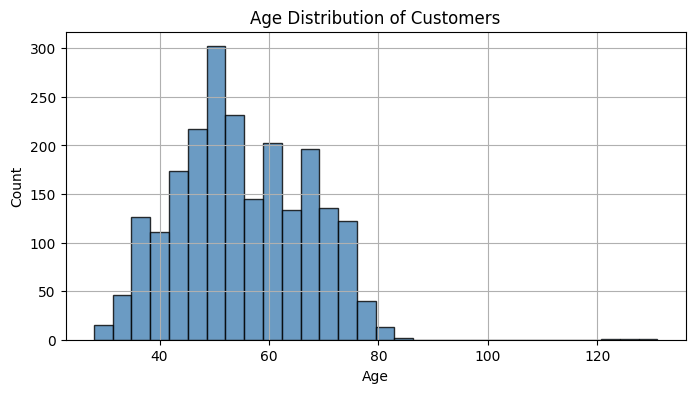

In [11]:
#Age distribution
plt.figure(figsize=(8, 4))
df['Age'].hist(bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show();

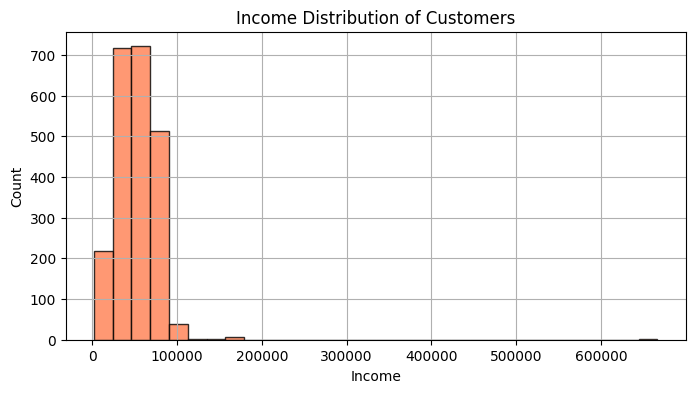

In [12]:
#Income distribution
plt.figure(figsize=(8, 4))
df['Income'].hist(bins=30, color='coral', edgecolor='black', alpha=0.8)
plt.title('Income Distribution of Customers')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show();

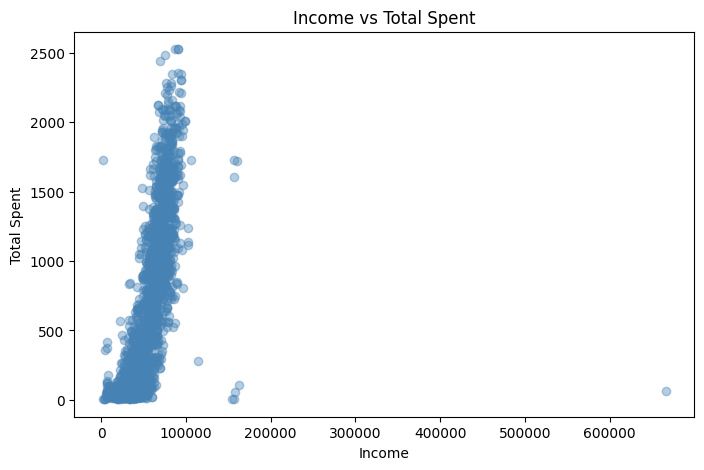

In [13]:
#Total Spent vs Income
plt.figure(figsize=(8, 5))
plt.scatter(df['Income'], df['Total_Spent'], alpha=0.4, color='steelblue')
plt.xlabel('Income')
plt.ylabel('Total Spent')
plt.title('Income vs Total Spent')
plt.show();

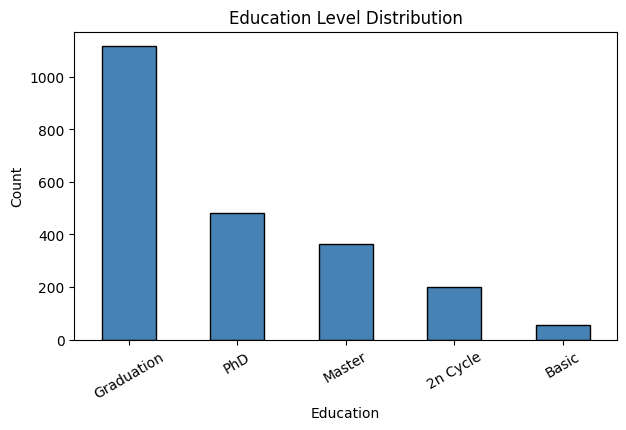

In [14]:
#Education breakdown
plt.figure(figsize=(7, 4))
df['Education'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Education Level Distribution')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show();

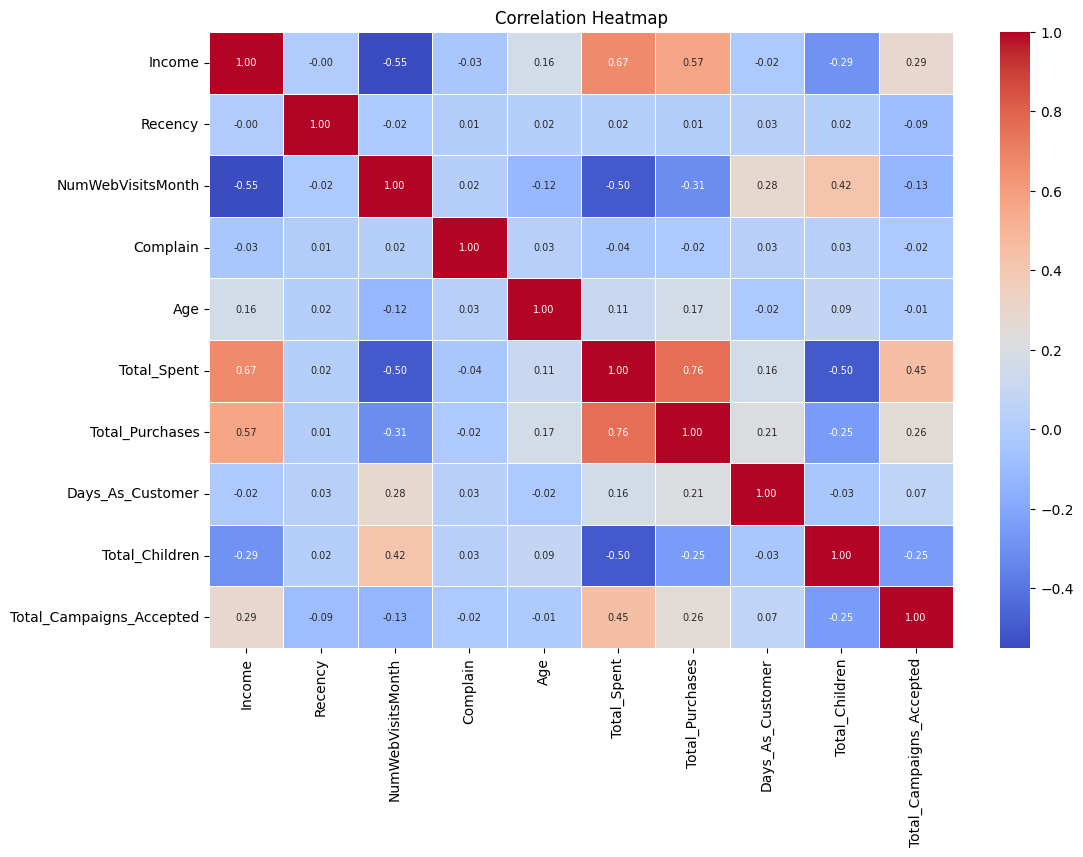

In [15]:
#Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr().round(2), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.show();

### Preprocessing

#### Encoding Categorical Columns

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'].astype(str))
df['Marital_Status'] = le.fit_transform(df['Marital_Status'].astype(str))

df.head()

,Education,Marital_Status,Income,Recency,NumWebVisitsMonth,Complain,Age,Total_Spent,Total_Purchases,Days_As_Customer,Total_Children,Total_Campaigns_Accepted
0,2,4,58138.0,58,7,0,67,1617,25,4136,0,1
1,2,4,46344.0,38,5,0,70,27,6,3586,2,0
2,2,5,71613.0,26,4,0,59,776,21,3785,0,0
3,2,5,26646.0,26,6,0,40,53,8,3612,1,0
4,4,3,58293.0,94,5,0,43,422,19,3634,1,0


#### Feature Scaling

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (2216, 12)


#### Dimensionality Reduction - PCA

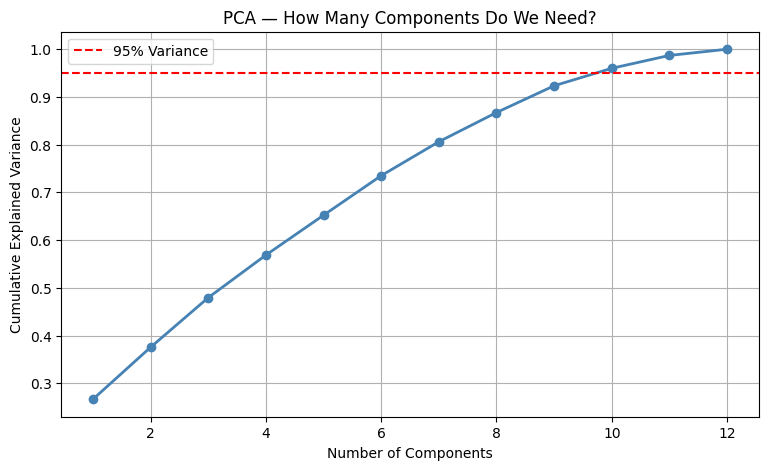

In [18]:
#Checking how many components explain 95% of variance
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_),
         marker='o', color='steelblue', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — How Many Components Do We Need?')
plt.legend()
plt.grid(True)
plt.show();

In [19]:
#Applying PCA keeping 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features : {X_scaled.shape[1]}")
print(f"After PCA         : {X_pca.shape[1]}")
print(f"Variance retained : {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original features : 12
After PCA         : 10
Variance retained : 96.01%


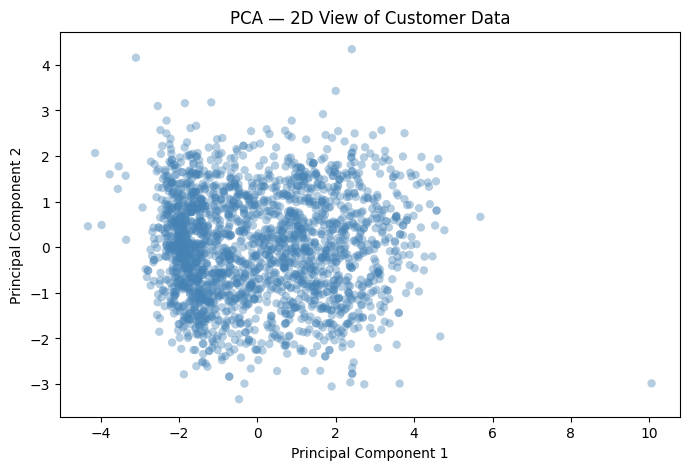

In [20]:
#2D projection for visualisation using two components
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4, color='steelblue', edgecolors='none')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA — 2D View of Customer Data')
plt.show();

#### K-Means Clustering

I used the Elbow Method to find the best K.

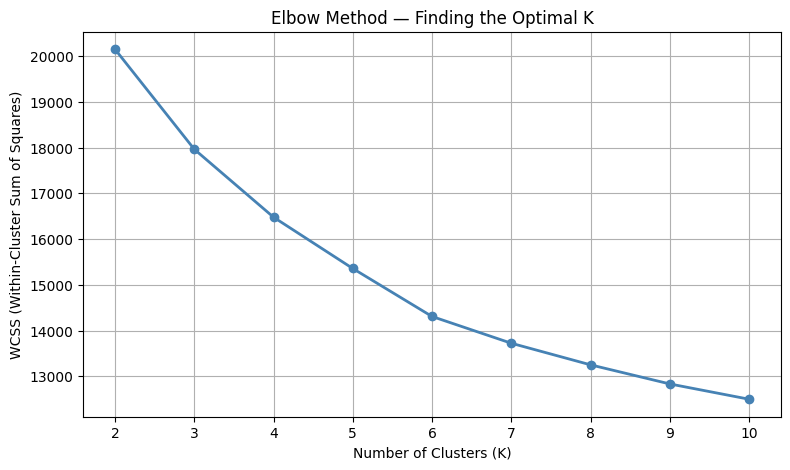

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Plot WCSS for K = 2 to 10
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method — Finding the Optimal K')
plt.grid(True)
plt.show();

In [22]:
#Silhouette scores to confirm best K
print("Silhouette Scores:")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"  K={k} : {score:.4f}")

Silhouette Scores:
  K=2 : 0.2119
  K=3 : 0.2213
  K=4 : 0.1574
  K=5 : 0.1301
  K=6 : 0.1381
  K=7 : 0.1302
  K=8 : 0.1245
  K=9 : 0.1190
  K=10 : 0.1154


In [23]:
#Applying K-Means with the best K
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, kmeans_labels)
print(f"(K={best_k}): {sil:.4f}")

(K=4): 0.1574


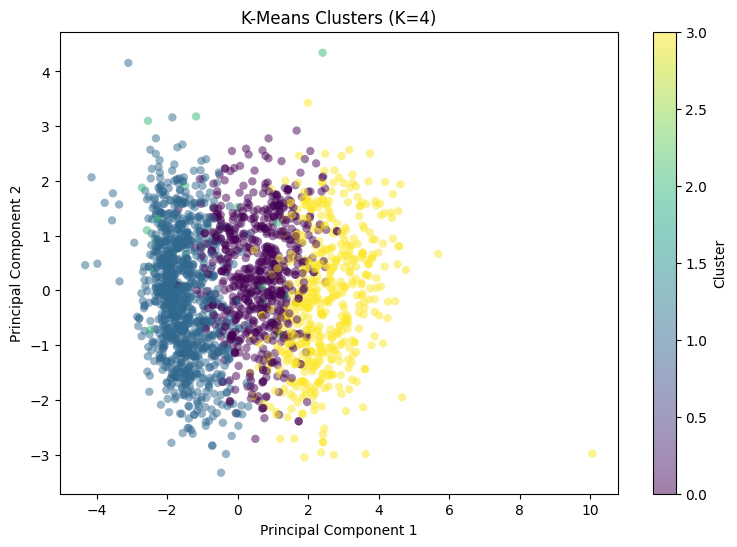

In [24]:
#Visualiseing K-Means clusters
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=kmeans_labels, cmap='viridis',
                      alpha=0.5, edgecolors='none')
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-Means Clusters (K={best_k})')
plt.show();

#### DBSCAN Clustering

In [25]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X_pca)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")

# Determing the Silhouette score excluding noise
mask = db_labels != -1
if mask.sum() > 1 and len(set(db_labels[mask])) > 1:
    sil_db = silhouette_score(X_pca[mask], db_labels[mask])
    print(f"Silhouette Score : {sil_db:.4f}")

Clusters found : 0
Noise points   : 2216


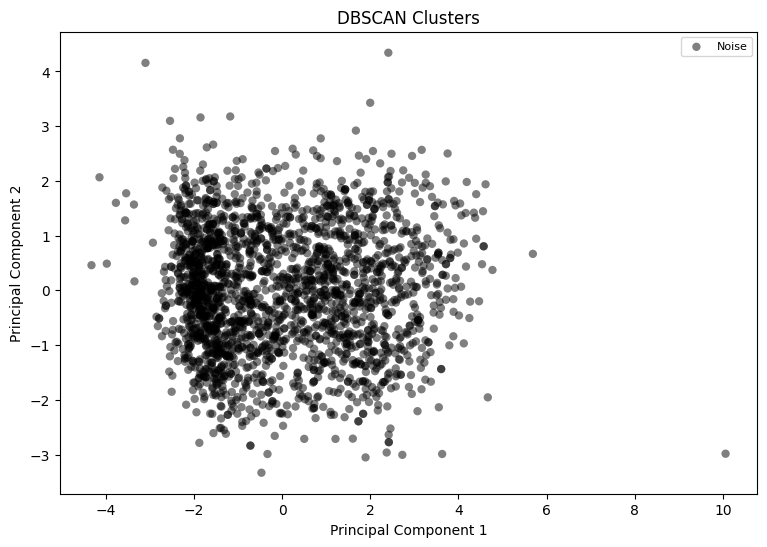

In [26]:
#Visualising the DBSCAN clusters
plt.figure(figsize=(9, 6))
unique_labels = set(db_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'
        label = 'Noise'
    else:
        label = f'Cluster {k}'
    mask = db_labels == k
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[col], alpha=0.5, label=label, edgecolors='none')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clusters')
plt.legend(loc='best', fontsize=8)
plt.show();

#### Cluster Interpretation

I added the K-Means cluster labels back to the original dataframe to analyse what makes each cluster unique.

In [27]:
df['Cluster'] = kmeans_labels

cluster_summary = df.groupby('Cluster')[['Age', 'Income', 'Total_Spent',
                                          'Total_Purchases', 'Total_Children',
                                          'Total_Campaigns_Accepted']].mean().round(2)
cluster_summary

,Age,Income,Total_Spent,Total_Purchases,Total_Children,Total_Campaigns_Accepted
Cluster,,,,,,
0,59.62,59114.65,810.96,21.57,1.13,0.36
1,52.19,34667.72,105.03,8.10,1.23,0.18
2,58.90,45242.29,376.43,13.24,1.19,0.29
3,55.29,79539.94,1377.55,20.03,0.12,1.13


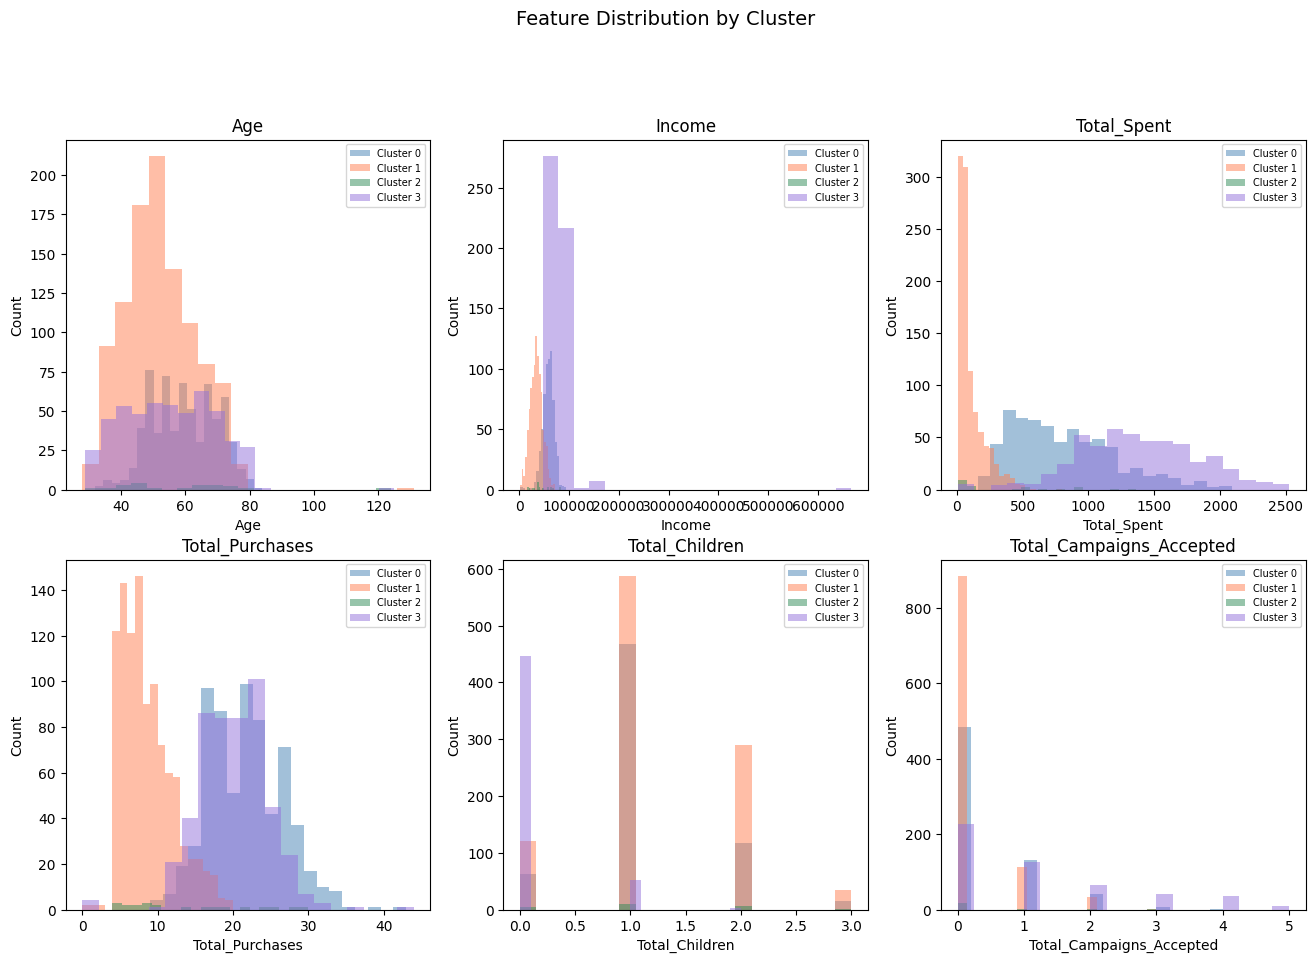

In [28]:
#Visualising key features across clusters
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features = ['Age', 'Income', 'Total_Spent',
            'Total_Purchases', 'Total_Children', 'Total_Campaigns_Accepted']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for ax, feature in zip(axes.flatten(), features):
    for cluster in range(best_k):
        data = df[df['Cluster'] == cluster][feature]
        ax.hist(data, bins=20, alpha=0.5, label=f'Cluster {cluster}',
                color=colors[cluster], edgecolor='none')
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distribution by Cluster', fontsize=14, y=1.01)
plt.show();

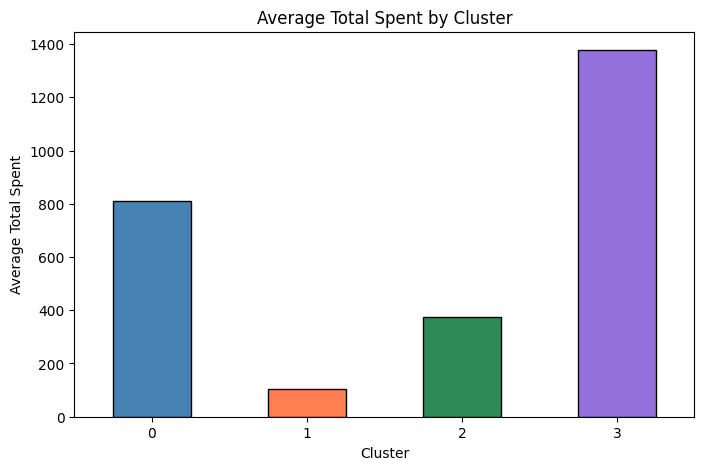

In [29]:
#Average Total Spent per cluster
plt.figure(figsize=(8, 5))
cluster_summary['Total_Spent'].plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average Total Spent by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Total Spent')
plt.xticks(rotation=0)
plt.show();

#### Conclusion

| Cluster | Characteristics |
|---|---|
| Cluster 0 | Loyal older customers. High income and spending but slightly less than Cluster 3 |
| Cluster 1 | Budget customers. Low income, barely spend, rarely shop. Need very different marketing, discount-focused |
| Cluster 2 | Middle ground customers. Moderate income and spending. Could be converted to higher spenders with the right offers |
| Cluster 3 | TPremium customers. Highest income, highest spending, no kids, most likely to accept campaigns. These are the most valuable customers to target |


**During the project cycle:**
- K-Means successfully grouped customers into distinct segments based on spending, income, age and purchasing behaviour
- PCA helped reduce the feature space and made the clusters easier to visualise
- DBSCAN identified outlier customers that do not fit neatly into any cluster
- Each cluster represents a different type of customer that the business can target differently